# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [2]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [4]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [6]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [7]:
# Estadísticas originales
print("=== Estadísticas originales ===")
print(data.describe())

# Estadísticas MinMaxScaler
print("\n=== Estadísticas MinMaxScaler ===")
print(data_minmax.describe())

=== Estadísticas originales ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

=== Estadísticas MinMaxScaler ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000      

Lo que pude observar es que ccon MinMax todas las variables fueron transformadas a un rango entre 0 y 1. 
A diferencia de las estadísticas originales, los valores mínimos ahora son cercanos a 0 y los máximos cercanos a 1, por lo que entendí en clase y el cuaderno wsto facilita que ninguna variable domine sobre las demás debido a su magnitud.

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

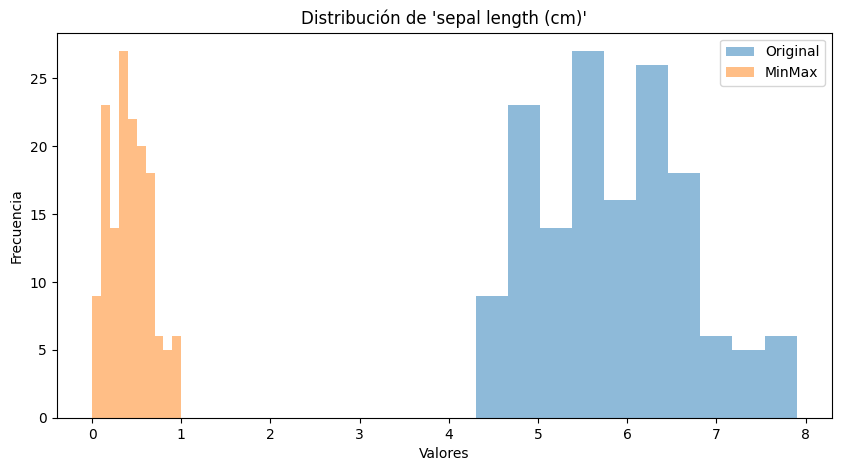

In [8]:
# Crear figura
plt.figure(figsize=(10,5))

# Datos originales
plt.hist(data['sepal length (cm)'], alpha=0.5, label='Original')

# Datos escalados
plt.hist(data_minmax['sepal length (cm)'], alpha=0.5, label='MinMax')

# Títulos y etiquetas
plt.title("Distribución de 'sepal length (cm)'")
plt.xlabel("Valores")
plt.ylabel("Frecuencia")

# Leyenda
plt.legend()

# Mostrar gráfica
plt.show()

Aqui se puede ver como la "forma" de las graficas son muy similares, la diferencia real es el rango en el que se encuentra, la parte original se ve entre un aproc de 4.2 y 8.8 (por poner valores redondos), mientras que el diagrama de MinMax se encuentra en un intervalo entre 0 y 1

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

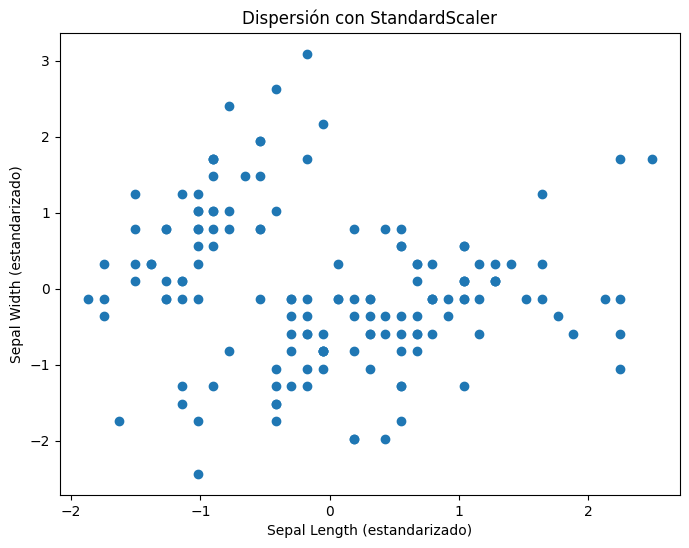

In [9]:
# Crear gráfica de dispersión
plt.figure(figsize=(8,6))

plt.scatter(
    data_standard['sepal length (cm)'],
    data_standard['sepal width (cm)']
)

# Títulos
plt.title("Dispersión con StandardScaler")
plt.xlabel("Sepal Length (estandarizado)")
plt.ylabel("Sepal Width (estandarizado)")

# Mostrar gráfica
plt.show()

Con la gráfica de dispersión podemos ver que los datos fueron centrados alrededor de 0 mediante StandardScaler y que la relación entre las variables se mantiene, pero ahora ambas tienen una media cercana a 0 y desviación estándar cercana a 1

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [10]:
# Comparar estadísticas básicas después de ambos escalados
print("=== MinMaxScaler ===")
print(data_minmax.describe())

print("\n=== StandardScaler ===")
print(data_standard.describe())

=== MinMaxScaler ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            0.428704          0.440556           0.467458   
std             0.230018          0.181611           0.299203   
min             0.000000          0.000000           0.000000   
25%             0.222222          0.333333           0.101695   
50%             0.416667          0.416667           0.567797   
75%             0.583333          0.541667           0.694915   
max             1.000000          1.000000           1.000000   

       petal width (cm)  
count        150.000000  
mean           0.458056  
std            0.317599  
min            0.000000  
25%            0.083333  
50%            0.500000  
75%            0.708333  
max            1.000000  

=== StandardScaler ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.500000e+02      1.500000e+02       1.500000e+02   
mean 

Para este conjunto de datos, creo que StandardScaler puede ser más adecuado porque las variables presentan distribuciones relativamente normales y este método centra los datos alrededor de la media con desviación estándar igual a 1, además por lo que tengo entendido muchos modelos de aprendizaje automático funcionan mejor cuando las variables están estandarizadas.

Pero MinMaxScaler también es útil cuando se requiere que los datos permanezcan dentro de un rango específico, especialmente en algoritmos sensibles a magnitudes como redes neuronales o KNN.